# Grain Shape Analysis Notebook

**Implementation of the Manuscript:**

This notebook corresponds to the implementation of the manuscript titled **"Using a Smartphone Device to Quantify Particle Size and Shape Descriptors"** by **Daniella Escribano**, **Carlos Kuncar Medina**, and **Gonzalo Montalva Alvarado** (November 2024). As authors, we plan to post the code on GitHub after the review process.

---

## Author Information

**Daniella Escribano, PhD**

- Department of Civil Engineering, Universidad de Concepción, Chile
- Fondecyt Iniciación Nº11241067, ANID, Chile
- Email: describano@udec.cl
- ORCID: 0000-0003-2014-9008

**Carlos Kuncar Medina, MSc. Candidate**

- Department of Civil Engineering, Universidad de Concepción, Chile
- Email: camedina2017@udec.cl

**Gonzalo Montalva Alvarado, PhD**

- Department of Civil Engineering, Universidad de Concepción, Chile
- EASER Project ACT240044, ANID, Chile
- Email: gmontalva@udec.cl
- ORCID: 0000-0001-8598-7120

---

## Abstract Summary

This notebook provides a procedure to obtain particle size and shape descriptors through a 2D image processing algorithm using a smartphone device. The open-source tool is automatic and requires only a simple initial calibration of the camera lens. The output consists of a spreadsheet with particle size and shape descriptors for each grain, as well as their average values for the entire sample. The tool benefits the geotechnical community due to the strong link between particle morphology and mechanical properties. An application is included where the script is used to obtain particle shape descriptors of a sand with known critical state parameters, evaluating them through particle shape predictive models. The results indicate that analyzing images with a minimum of 30 particles provides a good match with experimental data, highlighting the advantages of the tool as a first estimate and as a complement to a full experimental program.

---


# Notebook Guide

This notebook is organized into several sections, each with detailed instructions and explanations. Please run the cells by clicking on the top left corner of each cell (on the "Play" button ▶) to ensure that the analysis runs smoothly.

**Note:** This notebook is optimized for **Google Colab** and should be run using this platform.

---

## Running the Notebook in Google Colab

To execute this notebook in Google Colab, please follow these step-by-step instructions:

1. **Open Google Colab:**

   - Navigate to [Google Colaboratory](https://colab.research.google.com/) in your web browser.
   - Ensure you are signed in with your Google account.

2. **Upload the Notebook:**

   - In Google Colab, click on the **File** menu at the top left corner.
   - Select **Upload notebook** from the dropdown menu.
   - Click on the **Choose File** button and select the `FastGrains.ipynb` file from your local machine.
   - After selecting the file, click **Open** and then **Upload**.

In [1]:
#@title **1. Install third-party software**
#@markdown  🔙⬅ Click the "Play" button on the left to run this cell and install the necessary libraries for this Google Colab notebook. All installations are performed on Google Colab and not on your local machine.

%%capture
# Install necessary packages and dependencies
!git clone https://github.com/CASIA-IVA-Lab/FastSAM.git
%pip install -q -r FastSAM/requirements.txt
!wget -q https://huggingface.co/spaces/An-619/FastSAM/resolve/main/weights/FastSAM.pt
%pip install -q feret loess xlsxwriter
%pip install matplotlib==3.6.0


In [2]:
#@title **2. Creation of directories and loading of functions**
#@markdown This cell creates the necessary directories and provides a button for the *FastGRAINS.zip* file.

import os
import sys
import zipfile
import shutil
import ipywidgets as widgets
from IPython.display import display, clear_output
from google.colab import files

# Create necessary directories
if not os.path.exists('./FastGRAINS'):
    os.makedirs('./FastGRAINS')

sys.path.append('./FastGRAINS')  # Add FastGRAINS to system path
sys.path.append('./FastSAM')     # Add FastSAM to system path

# Create button for uploading scripts to FastGRAINS
script_upload_button = widgets.Button(description="Upload Scripts")
script_output = widgets.Output()

def on_script_upload_click(b):
    with script_output:
        clear_output()
        print("Please upload your zipped scripts (e.g., FastGRAINS.zip):")
        uploaded = files.upload()
        for filename in uploaded.keys():
            # Move the uploaded zip file to the FastGRAINS directory
            zip_path = os.path.join('./FastGRAINS', filename)
            shutil.move(filename, zip_path)

            # Decompress the zip file
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall('./FastGRAINS')

            # Remove the zip file after extraction
            os.remove(zip_path)

        print(f"Scripts uploaded and decompressed to FastGRAINS directory.")

script_upload_button.on_click(on_script_upload_click)
display(script_upload_button, script_output)


Button(description='Upload Scripts', style=ButtonStyle())

Output()

In [3]:
#@title **3. Importing the necessary functions**
#@markdown This cell imports all the required functions from the scripts.

# Import functions from your scripts
from image_io import create_directories, plot_image, upload_image, upload_images, plot_grids
from constants import set_material_name, IOU_THRESHOLD, DEVICE, IMAGE_SIZE, RESCALE, PAD, PCD_Target
from preprocessing import preprocess_image, postprocess_image, resize_image_keep_aspect
from background_removal import remove_background, invert_image
from segmentation import run_inference, load_annotations
from feature_extraction import get_bboxes, get_centroids, calculate_grain_metrics, save_metrics
from postprocessing import segment_and_store, remove_background_for_single_grain, resize_grains, grid_grains, save_grains
from utilities import resize_image, process_binary_image
from shape_metrics import compute_shape_metrics, compute_metrics_for_all_keys, resize_grains_to_PCD
from visualization import plot_grain, interactive_plot, draw_circles_on_grain
import gc


In [4]:
#@title **4. Enter the material name ⬇️**
#@markdown Enter the material name, e.g., **BBSAND** ⬇️

material_name = 'BBSAND20'  #@param {type:"string"}
set_material_name(material_name)  # Set the material name dynamically


In [5]:
#@title **5. Images Upload**
#@markdown Use this cell to upload images for analysis.

#@markdown ⚠️ If you want to process multiple images, consider splitting the processing into batches of approximately 5 images. Large images can exhaust the resources offered by Google Colab (RAM).

from constants import IMAGES_DIR, OUTPUT_DIR

# Upload images and set images_path
images_path = upload_images(material_name, IMAGES_DIR)
print(f"Images uploaded: {images_path}")


Saving SOBRE 20 BIOBIO-1.jpg to SOBRE 20 BIOBIO-1.jpg
Image uploaded: ./data/input/BBSAND20/2_BBSAND20.jpg
Images uploaded: ['./data/input/BBSAND20/2_BBSAND20.jpg']


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/content/./FastSAM/ultralytics/nn/tasks.py:518: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. Thi

Grid RGB image saved at: ./data/output/BBSAND20/2_BBSAND20/2_BBSAND20_Grid_RGB.png
Grid Bin image saved at: ./data/output/BBSAND20/2_BBSAND20/2_BBSAND20_Grid_Bin.png


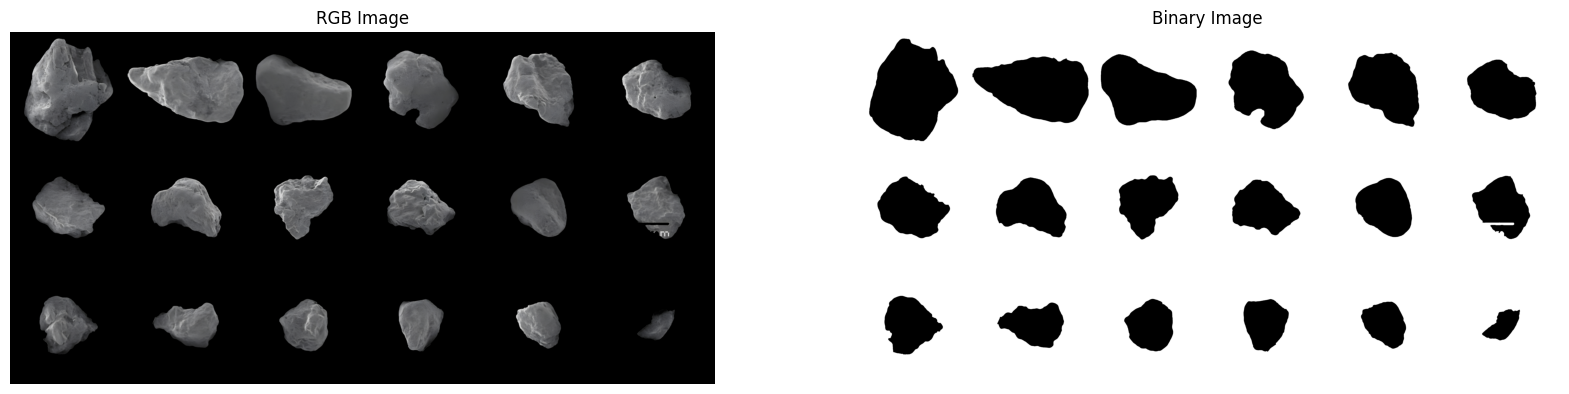

In [6]:
#@title **6. Segmentation batch process**
#@markdown This cell performs the segmentation and processing of uploaded images.

import gc
import shutil
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import clear_output
import numpy as np

# Parameters
span = 0.035
tol = 0.3
factor = 0.99
min_points = 3
num_cores = 1

def process_image(image_path):
    # Background Removal
    resized_path, black_background_path, white_background_path, avg_background_path, reduction_factor = remove_background(image_path, 2048, OUTPUT_DIR, RESCALE)

    # Segmentation
    annotations, output_path = run_inference(black_background_path, IMAGE_SIZE, IOU_THRESHOLD)

    # Load Annotations
    annotations = load_annotations(annotations, min_major_axis_length=int(10 / reduction_factor))
    gc.collect()

    # Feature Extraction
    bboxes = get_bboxes(annotations, PAD)
    centroids = get_centroids(annotations)

    # Post-processing
    grains = segment_and_store(annotations, bboxes, black_background_path, PAD)

    # Remove background for each grain
    grains = {grain_id: {**grain_data, "grain_rgb": remove_background_for_single_grain(grain_data, "black")} for grain_id, grain_data in grains.items()}
    resize_grains(grains, reduction_factor)
    calculate_grain_metrics(grains, reduction_factor, image_path)
    save_grains(grains, image_path, OUTPUT_DIR)

    # Create grid images
    grid_rgb_img, grid_bin_img = grid_grains(grains, image_path, rescale=True, background_color='black', output_dir=OUTPUT_DIR)
    gc.collect()

    # Resize grains to 1200 px of PCD
    resize_grains_to_PCD(grains, reduction_factor, PCD_Target=1200)

    # Plot the images
    plot_grids(grid_rgb_img, grid_bin_img)

    # Prefix grain_id with image_path to ensure uniqueness and add image_path to each grain's data
    grains = {f"{os.path.basename(image_path)}_{grain_id}": {**grain_data, "image_path": image_path} for grain_id, grain_data in grains.items()}
    gc.collect()
    plt.close('all')

    return grains

def main():
    all_grains = {}

    for image_path in images_path:
        try:
            grains = process_image(image_path)
            all_grains.update(grains)
        except Exception as exc:
            print(f'{image_path} generated an exception: {exc}')

    # Renumber the dictionary so that grain_id is enumerated from 0
    renumbered_grains = {i: grain_data for i, (grain_id, grain_data) in enumerate(all_grains.items())}
    gc.collect()

    return renumbered_grains

# Execute the main function
concatenated_grains = main()
grains = concatenated_grains.copy()


In [11]:
#@title **7. Find the optimal parameters for calculating roundness**
#@markdown ⬇️ Use the interactive buttons to adjust the parameters and visualise their effects. ⬇️
from ipywidgets import Button, HBox, VBox, IntSlider, FloatSlider, Output
from IPython.display import display, clear_output

# Create interactive widgets
id_slider = IntSlider(min=0, max=len(grains)-1, step=1, value=0, description='ID')
span_slider = FloatSlider(min=0.001, max=0.25, step=0.001, value=0.05, description='α', readout_format='.3f')
tol_slider = FloatSlider(min=0.01, max=1, step=0.01, value=0.3, description='δ', readout_format='.3f')
factor_slider = FloatSlider(min=0.98, max=1.0, step=0.001, value=0.981, description='T/R', readout_format='.4f')

# Function to update the sliders
def update_slider(slider, step):
    slider.value = round(slider.value + step, 3)

# Create buttons to move sliders in steps
id_up = Button(description='ID +1')
id_down = Button(description='ID -1')
span_up = Button(description='α +0.0025')
span_down = Button(description='α -0.0025')
tol_up = Button(description='δ +0.01')
tol_down = Button(description='δ -0.01')
factor_up = Button(description='T/R +0.001')
factor_down = Button(description='T/R -0.001')

# Link buttons to update functions
id_up.on_click(lambda b: update_slider(id_slider, 1))
id_down.on_click(lambda b: update_slider(id_slider, -1))
span_up.on_click(lambda b: update_slider(span_slider, 0.0025))
span_down.on_click(lambda b: update_slider(span_slider, -0.0025))
tol_up.on_click(lambda b: update_slider(tol_slider, 0.01))
tol_down.on_click(lambda b: update_slider(tol_slider, -0.01))
factor_up.on_click(lambda b: update_slider(factor_slider, 0.001))
factor_down.on_click(lambda b: update_slider(factor_slider, -0.001))

# Arrange buttons and sliders in a layout
controls = VBox([
    HBox([id_down, id_slider, id_up]),
    HBox([span_down, span_slider, span_up]),
    HBox([tol_down, tol_slider, tol_up]),
    HBox([factor_down, factor_slider, factor_up])
])

# Create an output widget for the plot
out = Output()

# Display the combined layout
display(controls, out)

def interactive_plot(id, span, tol, factor):
    grain_data = grains[id]
    try:
        metrics = compute_shape_metrics(grain_data["grain_bin_rs_PCD"], span, tol, factor, min_points=4)
        if metrics is None:
            print("compute_shape_metrics returned None")
            return
        convex, Roundness, Sa, Sc, Sd, Sp, Swl, AR, Cx, z, r, MCI, MCC, d1, d2, de, dins, dcir, minf, maxf = metrics
    except KeyError as e:
        print(f"KeyError: {e} is missing in grain_data")
        return
    with out:
        clear_output(wait=True)
        plot_grain(grain_data, convex, Roundness, Sa, Sd, Sp, Swl, AR, Cx, z, r, MCI, MCC)

# Call the interactive plot function when any slider value changes
def update_plot(*args):
    interactive_plot(id_slider.value, span_slider.value, tol_slider.value, factor_slider.value)

id_slider.observe(update_plot, 'value')
span_slider.observe(update_plot, 'value')
tol_slider.observe(update_plot, 'value')
factor_slider.observe(update_plot, 'value')

# Initial plot
interactive_plot(id_slider.value, span_slider.value, tol_slider.value, factor_slider.value)


Output()

In [ ]:
#@title **8. Calculate the metrics of all grains with the selected parameters for roundness calculation using the adaptation of the algorithm of Zheng & Hryciw 2015**.
#@markdown Enter the selected parameters:

#@markdown smooth parameter, α: ⬇️
span = 0.045  #@param {type:"number", label:"α (span)"}
#@markdown parameter, δ : ⬇️
tol = 0.2    #@param {type:"number", label:"δ (tol)"}
#@markdown factor, T/R ⬇️
factor = 0.9840  #@param {type:"number", label:"T/R (factor)"}
#@markdown minimum points: ⬇️
min_points = 3  #@param {type:"number", label:"Minimum Points (min_points)"}

compute_metrics_for_all_keys(grains, span, tol, factor, min_points)


In [ ]:
#@title **9. Shape calculation and export results**
#@markdown This cell processes the bean data, formats the DataFrame and exports the results to a zip file that includes an excel file and the output images.
#@markdown Please wait until the *data_zip* file is downloaded.
from data_export import export_to_excel, shape_calculation, DATA_DIR, save_data_as_zip, plot_granulometric_curve, plot_density_curves
import pandas as pd

# Assuming you have a dictionary called 'grains' with your grain data
grains_df = shape_calculation(grains, output_excel_filename='grains_data.xlsx')

# Plot the granulometric curve
# plot_granulometric_curve(grains_df)

# Plot density curves
plot_density_curves(grains_df)
save_data_as_zip()

In [ ]:
# # image_url = "/content/1_20BBr_10_bin.png"

# image = Image.open(image_url)

gray =  np.array(image)
gray = cv2.bitwise_not(gray)
contours, _ = cv2.findContours(gray.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
cnt = contours[0].squeeze().reshape(-1, 2)

max_inscribed_radius = get_max_inscribed_radius(gray.astype(np.uint8))

centroid = np.mean(cnt, axis=0)

# 1. Polar conversion
theta, r = convert_to_polar_fixed_angular(cnt, centroid)

# 2. Auto cutoff selection
cutoff_wavelength = auto_cutoff_selection(r)

cutoff_freq=1/cutoff_wavelength

# plot_frequency_spectrum(r, cutoff_freq) # Example cutoff

# 3. Filtering
r_filtered = gaussian_regression_filter(r, cutoff_wavelength)
# 4. Reconstruct smoothed contour
x = centroid[0] + r_filtered * np.cos(theta)
y = centroid[1] + r_filtered * np.sin(theta)

smoothed_contour = np.stack([x, y], axis=1).astype(np.float32)
smoothed_contour = enforce_ccw(smoothed_contour)

In [ ]:
#@title **10. Download Results**
#@markdown Please wait until the `data.zip` file is downloaded.
#@markdown Downloads from Google Colab can be slow. Alternatively, you can click on the folder icon 📁 on the left side of this cell (files), locate the `data.zip` file, and right-click to download it using the *Download* option.

from google.colab import files

# Download the zip file
files.download("data.zip")

## 11. Explanation of Excel Results

The Excel file generated from the grain shape analysis contains several columns with detailed information for each grain. Below is an explanation of each column:

### **Identification and Images**

- **`grain_id`**: Unique identifier assigned to each grain analyzed.
- **`grain_results`**: Image of the grain with circles overlaid, showing the results of the shape analysis (e.g., inscribed circle, circumscribed circle).
- **`grain_rs_PCD`**: Resized binary image of the grain adjusted to the Particle Characteristic Dimension (PCD), used for consistent scale in analysis.

### **Size Measurements** *(in pixel units)*

The following columns represent size measurements and are **in pixel units**:

- **`dins`**: Diameter of the largest inscribed circle within the grain.
- **`dcir`**: Diameter of the smallest circumscribed circle that encloses the grain.
- **`minf`**: Minimum Feret diameter (smallest distance between two parallel tangents on opposite sides of the grain).
- **`maxf`**: Maximum Feret diameter (largest distance between two parallel tangents on opposite sides of the grain).
- **`d1`**: Length of the major axis of the grain (maximum dimension).
- **`d2`**: Length of the minor axis of the grain (minimum dimension).

### **Shape Descriptors**

- **`de`**: Equivalent diameter.
- **`Roundness`**: Measure of the grain's roundness based on the curvature of its edges, following the method by Zheng and Hryciw (2015).
- **`AR`**: Aspect Ratio, calculated as the ratio of the major axis length to the minor axis length (\( AR = \frac{d1}{d2} \)).
- **`Cx`**: Convexity.
- **`Sa`**: Area Sphericity.
- **`Sc`**: Circular ratio sphericity.
- **`Sd`**: Diameter-Sphericity.
- **`Sp`**: Perimeter Sphericity based.
- **`Swl`**: Width to Length ratio Shpericity.

### **Notes on Units**

- The size measurements (**`dins`**, **`dcir`**, **`minf`**, **`maxf`**, **`d1`**, **`d2`**) are in **pixel units**. These values are derived from the images and represent relative sizes based on the image resolution.
- The shape descriptors are **dimensionless** quantities that describe the grain's shape characteristics independent of size.

### **Understanding the Measurements**

- **Size Measurements**: Useful for understanding the physical dimensions and size distribution of the grains within the sample. While provided in pixel units, these can be converted to real-world units (e.g., millimeters) if the scale of the images is known.
- **Shape Descriptors**: Provide insights into the morphological characteristics of the grains, which can influence the material's mechanical properties, such as strength and permeability.

### **Reference**

The methods and calculations for the roundness and sphericity parameters are based on:

- **Zheng, J., & Hryciw, R. D. (2015).** Traditional soil particle sphericity, roundness, and surface roughness by computational geometry. *Géotechnique*, 65(6), 494-506.

---

**Tip**: To convert pixel units to actual measurements, you need to know the scale of your images (e.g., pixels per millimeter). Once the scale is determined through calibration, you can multiply the pixel measurements by the scale factor to obtain real-world dimensions.

---

**Understanding these parameters will help in assessing the grain morphology and predicting the behavior of granular materials in geotechnical applications.**


## 12. Acknowledgements:    

The roundness calculation implemented in this notebook is based on the Matlab code by Zheng and Hryciw (2015):

Zheng, J., & Hryciw, R. D. (2015). Traditional soil particle sphericity, roundness and surface roughness by computational geometry. Géotechnique, 65(6), 494-506.

We thank the authors for their contributions to the field and for providing the basis for our implementation.

### Additional Acknowledgements

This project also utilizes resources and tools from the following repositories:

- [RMBG-1.4](https://huggingface.co/briaai/RMBG-1.4)
- [Fast Segment Anything](https://github.com/CASIA-IVA-Lab/FastSAM)
